# Лабораторная работа 1.

# Задание 1
Выбрать датасет, в котором есть количественный атрибут, который «хочется предсказывать», и хотя бы 3 количественные переменные.

Реализовать самостоятельно (разрешается пользоваться матричными вычислениями из numpy и средствами решения задач оптимизации из scipy или других модулей) модель линейной регрессии вместе со свободным коэффициентом (в качестве спортивного интереса можно сравнить результат своей модели с, например, функцией из statsmodels).

Вывести оценки для свободного коэффициента и при переменных, оценку остаточной дисперсии, коэффициент детерминации.

Построить 0.95 доверительные интервалы для коэффициентов модели и остаточной дисперсии.

Проверить статистическую значимость каждой из переменных и модели в целом (нулевая гипотеза: все коэффициенты за исключением свободного равны нулю) [выводить значение статистики и p-value].

Проверить, выполняются ли посылки теоремы Гаусса–Маркова и основной теоремы о линейной регрессии для конкретного датасета.


In [63]:
from itertools import combinations
from pathlib import Path
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import seaborn as sns

## Данные
Используем датасет Car Price Prediction. Целевая переменная - цена автомобиля.

In [2]:
dataset_dir = Path(kagglehub.dataset_download("hellbuoy/car-price-prediction/versions/1"))

In [3]:
csv_path = next(dataset_dir.rglob("CarPrice_Assignment.csv"))
print("CSV найден тут:", csv_path)

data = pd.read_csv(csv_path, encoding='latin-1')
data.head()

CSV найден тут: C:\Users\Professional\.cache\kagglehub\datasets\hellbuoy\car-price-prediction\versions\1\CarPrice_Assignment.csv


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
data.columns.tolist()

['car_ID',
 'symboling',
 'CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginetype',
 'cylindernumber',
 'enginesize',
 'fuelsystem',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

In [5]:
data.dtypes

car_ID                int64
symboling             int64
CarName                 str
fueltype                str
aspiration              str
doornumber              str
carbody                 str
drivewheel              str
enginelocation          str
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype              str
cylindernumber          str
enginesize            int64
fuelsystem              str
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [6]:
cols = [
    'price', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
    'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
    'horsepower', 'peakrpm', 'citympg', 'highwaympg'
]

data_clean = data[cols].copy()

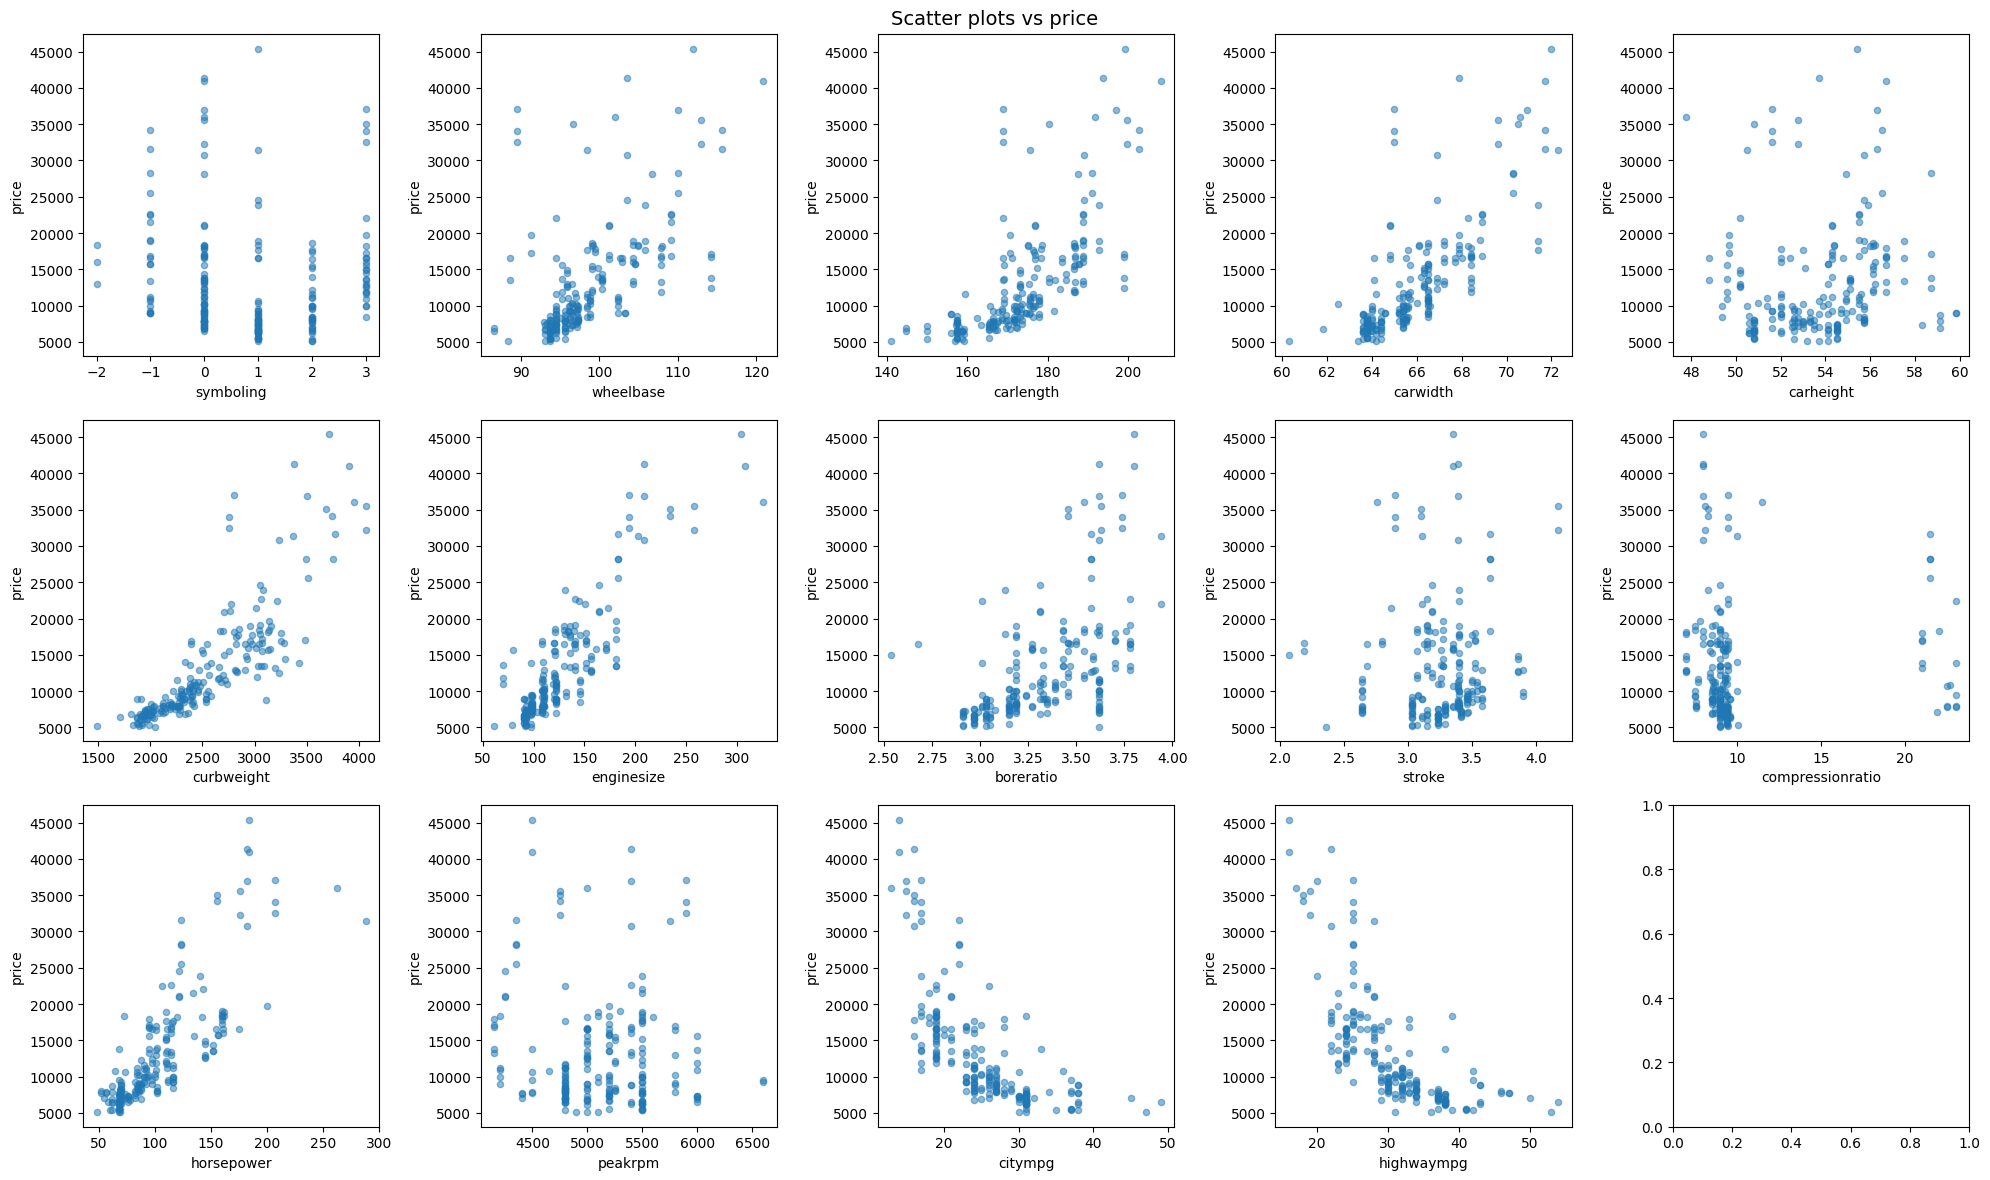

In [7]:
predictors = [c for c in cols if c != 'price']
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(data_clean[col], data_clean['price'], alpha=0.5, s=20)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')

plt.suptitle("Scatter plots vs price", fontsize=14)
plt.tight_layout()
plt.show()

Первоначально рассматривались все доступные количественные переменные: symboling, wheelbase, carlength, carwidth, carheight, curbweight, enginesize, boreratio, stroke, compressionratio, horsepower, peakrpm, citympg, highwaympg. Переменные carheight, stroke, compressionratio, symboling показали связь с ценой близкую к нулю и были исключены. Из пары citympg/highwaympg оставлен citympg как менее коллинеарный с остальными.

In [8]:
predictors = ['enginesize', 'curbweight', 'horsepower', 'carwidth',
              'carlength', 'wheelbase', 'citympg', 'peakrpm', 'boreratio']
target = 'price'

df = data_clean[predictors + [target]].copy()

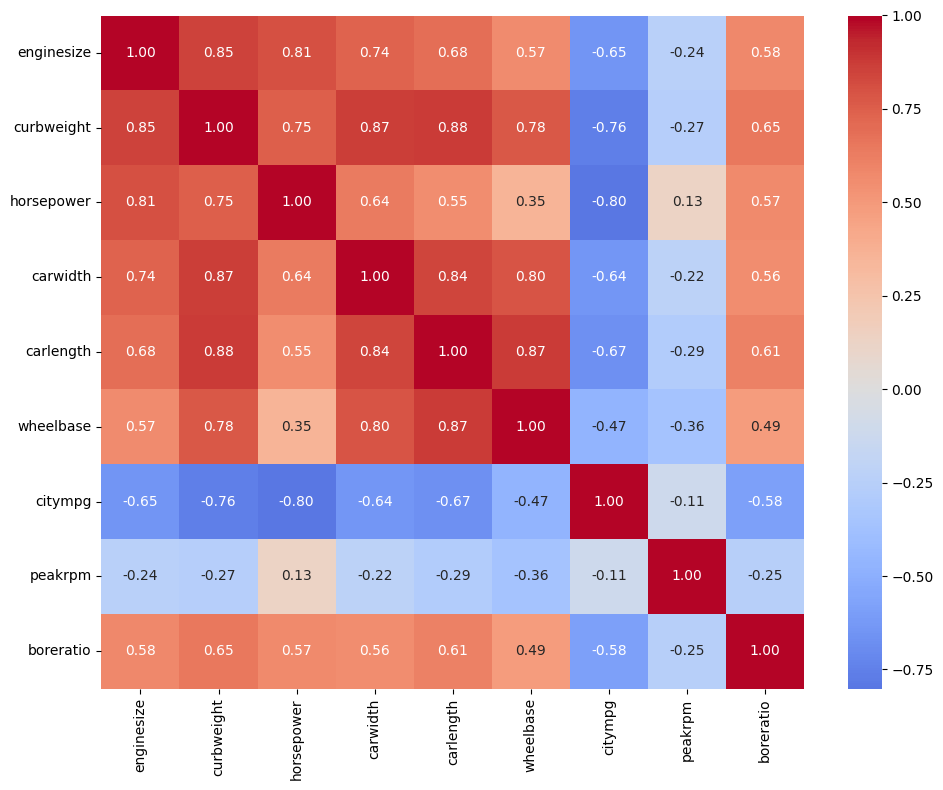

In [9]:
corr_matrix = df[predictors].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

Видна сильная мультиколлинеарность: пары curbweight/carlength (0.88), curbweight/carwidth (0.87), carlength/wheelbase (0.87) превышают порог 0.85. Из каждой такой группы оставлен один представитель. Итоговый набор признаков: enginesize, horsepower, citympg, peakrpm, boreratio.

In [10]:
predictors = ['enginesize', 'horsepower', 'citympg', 'peakrpm', 'boreratio']
target = 'price'

df = data[predictors + [target]].copy()

In [11]:
print(df[predictors].corr().round(2))

            enginesize  horsepower  citympg  peakrpm  boreratio
enginesize        1.00        0.81    -0.65    -0.24       0.58
horsepower        0.81        1.00    -0.80     0.13       0.57
citympg          -0.65       -0.80     1.00    -0.11      -0.58
peakrpm          -0.24        0.13    -0.11     1.00      -0.25
boreratio         0.58        0.57    -0.58    -0.25       1.00


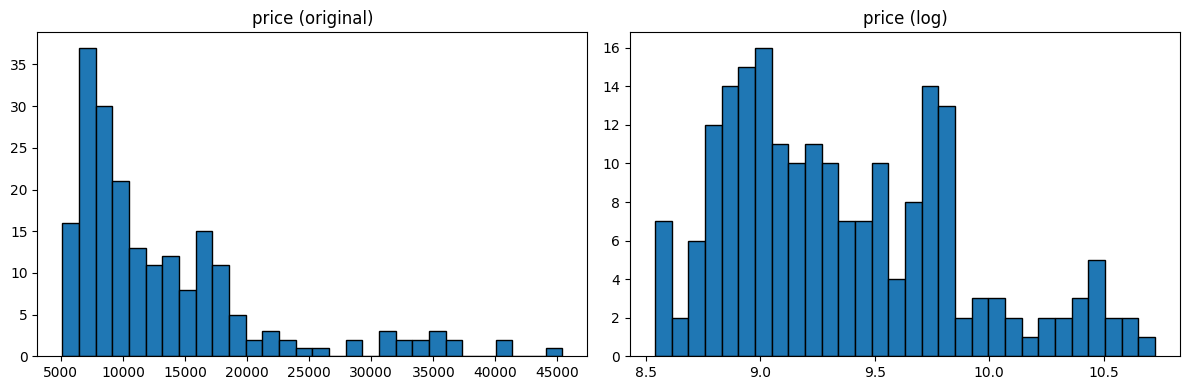

Skew price: 1.78
Skew log_price: 0.67


In [12]:
df['log_price'] = np.log(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=30, edgecolor='black')
axes[0].set_title('price (original)')
axes[1].hist(df['log_price'], bins=30, edgecolor='black')
axes[1].set_title('price (log)')
plt.tight_layout()
plt.show()

print(f"Skew price: {df['price'].skew():.2f}")
print(f"Skew log_price: {df['log_price'].skew():.2f}")

Распределение price заметно скошено вправо (skew = 1.78). После логарифмирования коэффициент снижается до 0.67. Далее работаем с логарифмом цены как целевой переменной.

## Модель линейной регрессии
Рассматриваем модель:
$$  Y = X \beta + \varepsilon $$
где
Y - вектор значений $\log(\text{price})$

X - матрица признаков с добавленным столбцом единиц для свободного коэффициента,

$\beta$ - вектор неизвестных коэффициентов. Оценка МНК:

$$ \hat{\beta} = (X^TX)^{-1}X^TY $$

In [13]:
predictors = ['enginesize', 'horsepower', 'citympg', 'peakrpm', 'boreratio']
target = 'price'

df = data[predictors + [target]].copy()

y = np.log(df[target].values)
X_raw = df[predictors].values
n, p = X_raw.shape

X = np.column_stack([np.ones(n), X_raw])  # (n, p+1)

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Размер X: (205, 6)
Размер y: (205,)


In [14]:
XtX = X.T @ X
Xty = X.T @ y
beta = np.linalg.solve(XtX, Xty)

labels = ['intercept'] + predictors
for name, b in zip(labels, beta):
    print(f"  {name:20s}: {b:.4f}")

  intercept           : 8.7576
  enginesize          : 0.0050
  horsepower          : 0.0030
  citympg             : -0.0216
  peakrpm             : -0.0000
  boreratio           : 0.1140


In [15]:
X_sm = sm.add_constant(df[predictors])
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     154.9
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.36e-66
Time:                        22:40:16   Log-Likelihood:                 12.880
No. Observations:                 205   AIC:                            -13.76
Df Residuals:                     199   BIC:                             6.177
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7576      0.471     18.591      0.0

## Оценки коэффициентов, остаточная дисперсия, R^2

Несмещённая оценка остаточной дисперсии:

$$ \hat{\sigma}^2 = \frac{S^2(\hat{\beta})}{n - m} $$

где m = p + 1 - число параметров включая свободный коэффициент.

In [16]:
y_hat = X @ beta
residuals = y - y_hat

RSS = residuals @ residuals
s2 = RSS / (n - p - 1)
s = np.sqrt(s2)

TSS = np.sum((y - np.mean(y)) ** 2)
R2 = 1 - RSS / TSS

print(f"Сумма квадратов остатков: {RSS:.2f}")
print(f"Остаточная дисперсия s2: {s2:.2f}")
print(f"Стандартная ошибка s: {s:.2f}")
print(f"Коэффициент детерминации R2:{R2:.4f}")

Сумма квадратов остатков: 10.59
Остаточная дисперсия s2: 0.05
Стандартная ошибка s: 0.23
Коэффициент детерминации R2:0.7956


Модель объясняет около 80% вариации log(price). Стандартная ошибка 0.23 в логарифмической шкале соответствует примерно +-23% относительной ошибки по цене.

## Доверительные интервалы

По основной теореме о нормальной регрессии:

$$ \frac{\hat{\beta}_j - \beta_j}{\hat{\sigma}\sqrt{(X^TX)^{-1}_{jj}}} \sim T(n - m) $$

Доверительный интервал уровня 0.95 для $\beta_j$:

$$ \hat{\beta}_j \pm t_{0.975,\, n-m} \cdot \hat{\sigma}\sqrt{(X^TX)^{-1}_{jj}} $$

Для остаточной дисперсии используется $\frac{S^2(\hat{\beta})}{\sigma^2} \sim \chi^2(n - m)$:

$$ \left(\frac{\text{RSS}}{\chi^2_{0.975,\, n-m}},\ \frac{\text{RSS}}{\chi^2_{0.025,\, n-m}}\right) $$

In [17]:
XtX_inv = np.linalg.inv(XtX)
var_beta = s2 * XtX_inv
se_beta = np.sqrt(np.diag(var_beta))

t_crit = stats.t.ppf(0.975, df=n - p - 1)

print(f"t_крит (0.975, df={n - p - 1}): {t_crit:.4f}\n")
print(f"{'Переменная':20s} {'Оценка':>12s} {'Ст.ошибка':>12s} {'CI lower':>12s} {'CI upper':>12s}")
print("-" * 72)
for i, name in enumerate(labels):
    ci_lo = beta[i] - t_crit * se_beta[i]
    ci_hi = beta[i] + t_crit * se_beta[i]
    print(f"{name:20s} {beta[i]:12.4f} {se_beta[i]:12.4f} {ci_lo:12.4f} {ci_hi:12.4f}")

t_крит (0.975, df=199): 1.9720

Переменная                 Оценка    Ст.ошибка     CI lower     CI upper
------------------------------------------------------------------------
intercept                  8.7576       0.4711       7.8287       9.6866
enginesize                 0.0050       0.0008       0.0034       0.0066
horsepower                 0.0030       0.0010       0.0010       0.0050
citympg                   -0.0216       0.0043      -0.0301      -0.0131
peakrpm                   -0.0000       0.0000      -0.0001       0.0001
boreratio                  0.1140       0.0831      -0.0499       0.2779


Интервалы для enginesize, horsepower и citympg не содержат ноль. Для peakrpm и boreratio - содержат, что указывает на их незначимость.

In [18]:
df_res = n - p - 1
chi2_lo = stats.chi2.ppf(0.025, df=df_res)
chi2_hi = stats.chi2.ppf(0.975, df=df_res)

ci_s2_lo = RSS / chi2_hi
ci_s2_hi = RSS / chi2_lo

print(f"Остаточная дисперсия s2: {s2:.2f}")
print(f"95% CI: [{ci_s2_lo:.2f}, {ci_s2_hi:.2f}]")

Остаточная дисперсия s2: 0.05
95% CI: [0.04, 0.07]


95% доверительный интервал для остаточной дисперсии: [0.04, 0.07].

## Проверка значимости

### t-тест: значимость каждого признака

Для каждого коэффициента проверяется

H0: beta_j = 0

H1: beta_j != 0.

Статистика:

$$ t_j = \frac{\hat{\beta}_j}{\hat{\sigma}\sqrt{(X^TX)^{-1}_{jj}}} \sim T(n-m) \text{ при } H_0 $$

In [19]:
t_stats = beta / se_beta
p_values = 2 * stats.t.sf(np.abs(t_stats), df=df_res)

print(f"{'Переменная':20s} {'beta':>10s} {'t-статистика':>14s} {'p-value':>12s} {'Значима?':>10s}")
print("-" * 70)
for i, name in enumerate(labels):
    sig = "да" if p_values[i] < 0.05 else "нет"
    print(f"{name:20s} {beta[i]:10.4f} {t_stats[i]:14.4f} {p_values[i]:12.4f} {sig:>10s}")

Переменная                 beta   t-статистика      p-value   Значима?
----------------------------------------------------------------------
intercept                8.7576        18.5907       0.0000         да
enginesize               0.0050         6.0501       0.0000         да
horsepower               0.0030         2.9260       0.0038         да
citympg                 -0.0216        -5.0207       0.0000         да
peakrpm                 -0.0000        -0.7859       0.4329        нет
boreratio                0.1140         1.3711       0.1719        нет


Значимы на уровне 0.05: enginesize (p ~ 0), horsepower (p = 0.004), citympg (p ~ 0).
Незначимы: peakrpm (p = 0.43) и boreratio (p = 0.17) - вероятно, вследствие остаточной мультиколлинеарности.

### F-тест: значимость модели в целом

Проверяется H0: beta_1 = ... = beta_p = 0. Статистика:

$$ F = \frac{(TSS - RSS)/p}{RSS/(n-m)} \sim F(p,\, n-m) \text{ при } H_0 $$

In [20]:
MSR = (TSS - RSS) / p
MSE = RSS / df_res

F_stat = MSR / MSE
p_value_F = stats.f.sf(F_stat, dfn=p, dfd=df_res)

print(f"F-статистика: {F_stat:.4f}")
print(f"p-value:      {p_value_F:.6f}")
print(f"Модель значима: {'да' if p_value_F < 0.05 else 'нет'}")

F-статистика: 154.8854
p-value:      0.000000
Модель значима: да


F = 154.89, p ~ 0 - H0 отвергается, модель статистически значима в целом.

## Проверка теорем

Теорема Гаусса-Маркова утверждает, что оценка МНК является несмещённой и оптимальной
в классе линейных несмещённых оценок при условиях:

1. E[eps] = 0 - отсутствие систематической ошибки
2. Cov(eps_i, eps_j) = 0 при i != j - некоррелированность остатков
3. Var(eps_i) = sigma^2 - гомоскедастичность

Основная теорема о линейной регрессии дополнительно требует:

4. eps ~ N(0, sigma^2 * E_n)

Условие 4 необходимо для того, чтобы t- и F-статистики имели точные, а не асимптотические распределения.

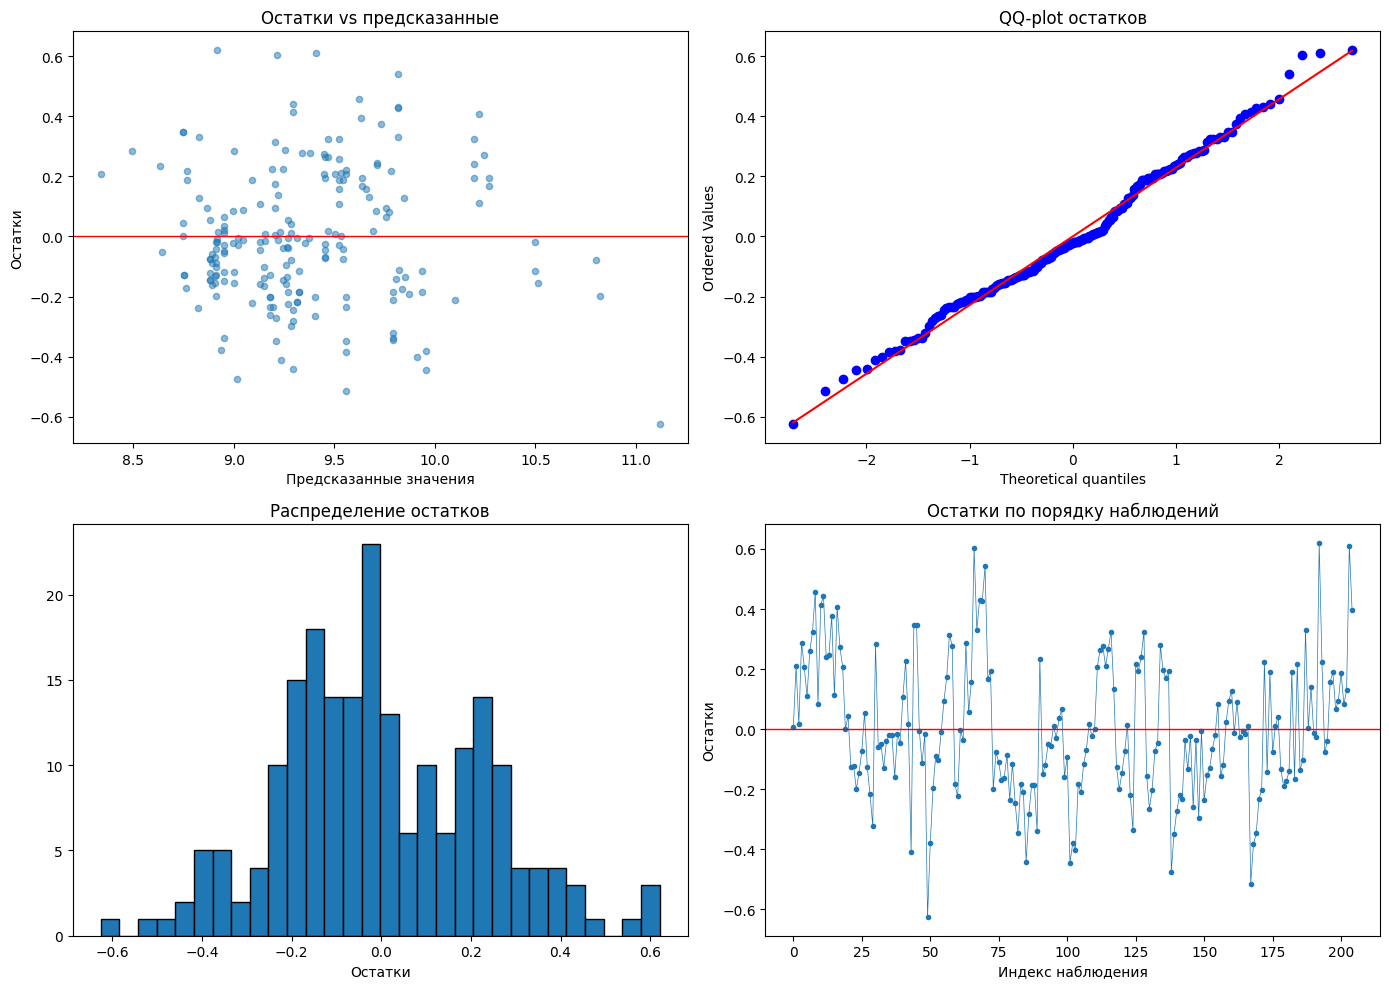

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_hat, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(0, color='red', linewidth=1)
axes[0, 0].set_xlabel("Предсказанные значения")
axes[0, 0].set_ylabel("Остатки")
axes[0, 0].set_title("Остатки vs предсказанные")

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("QQ-plot остатков")

axes[1, 0].hist(residuals, bins=30, edgecolor='black')
axes[1, 0].set_xlabel("Остатки")
axes[1, 0].set_title("Распределение остатков")

axes[1, 1].plot(residuals, marker='o', markersize=3, linewidth=0.5)
axes[1, 1].axhline(0, color='red', linewidth=1)
axes[1, 1].set_xlabel("Индекс наблюдения")
axes[1, 1].set_ylabel("Остатки")
axes[1, 1].set_title("Остатки по порядку наблюдений")

plt.tight_layout()
plt.show()

In [22]:
stat_sw, p_sw = stats.shapiro(residuals)
print(f"Шапиро-Уилк: W={stat_sw:.4f}, p={p_sw:.4f} - нормальность {'не отвергается' if p_sw > 0.05 else 'отвергается'}")

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)
print(
    f"Бройш-Паган: stat={bp_stat:.4f}, p={bp_p:.4f} - гомоскедастичность {'не отвергается' if bp_p > 0.05 else 'отвергается'}")

dw = durbin_watson(residuals)
print(f"Дарбин-Уотсон: DW={dw:.4f} - {'нет автокорреляции' if 1.5 < dw < 2.5 else 'возможна автокорреляция'}")

Шапиро-Уилк: W=0.9893, p=0.1313 - нормальность не отвергается
Бройш-Паган: stat=19.0255, p=0.0019 - гомоскедастичность отвергается
Дарбин-Уотсон: DW=0.9039 - возможна автокорреляция


Результаты:

- Условие 1 (E[eps] = 0) - выполняется по построению МНК
- Условие 4, нормальность (Шапиро-Уилк: W = 0.989, p = 0.13) - не отвергается
- Условие 3, гомоскедастичность (Бройш-Паган: p = 0.002) - нарушено;
  на графике остатков виден воронкообразный разброс, дисперсия растёт
  с ростом предсказанных значений
- Условие 2, некоррелированность (Дарбин-Уотсон: DW = 0.90) - нарушено;
  значение существенно ниже 2, что свидетельствует о положительной
  автокорреляции остатков; вероятная причина - наблюдения упорядочены
  по маркам автомобилей, а не случайно

Посылки 2 и 3 теоремы Гаусса-Маркова нарушены, поэтому оценки МНК
перестают быть оптимальными, а стандартные ошибки коэффициентов -
некорректными. Нормальность остатков при этом не отвергается, однако
из-за гетероскедастичности доверительные интервалы и p-value следует
интерпретировать с осторожностью.

# Задание № 2

Выберите датасет, в котором есть количественный атрибут, который «хочется предсказывать» и хотя бы 1 категориальная переменная

Реализуйте самостоятельно модель однофакторного дисперсионного анализа (ради интереса можете сравнить со statsmodels или scipy). Проверьте значимость фактора (выведите F-статистику и p-value)

Проверьте предположения на модель однофакторного дисперсионного анализа для вашего конкретного датасета

In [23]:
data = pd.read_csv(r'C:\Users\Professional\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1\possum.csv')
data

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


Зададимся вопросом: есть ли статистически значимые различия в средней длине тела (totlngth) у опоссумов, пойманных в разных местах (site)? Рассмотрим сначала на графиках, а затем формально с помощью однофакторного дисперсионного анализа.

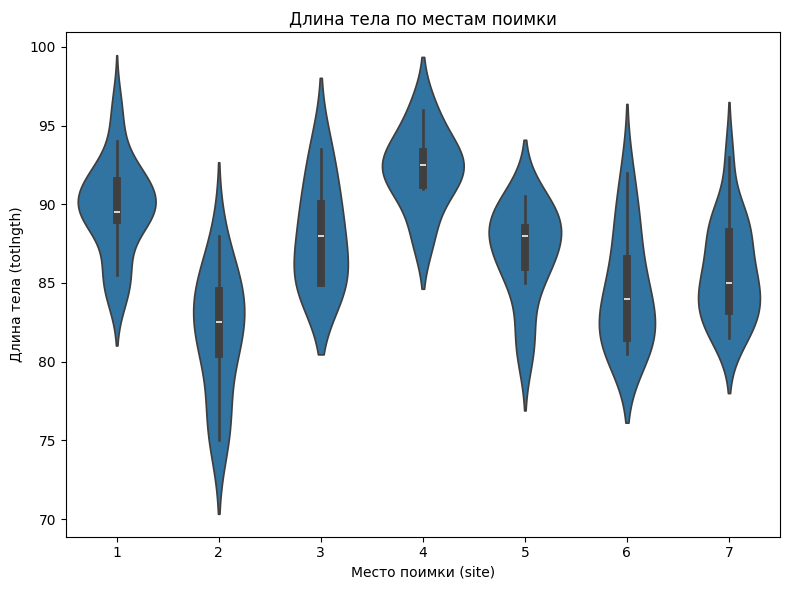

In [24]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='site', y='totlngth', data=data)
plt.title("Длина тела по местам поимки")
plt.xlabel("Место поимки (site)")
plt.ylabel("Длина тела (totlngth)")
plt.tight_layout()
plt.show()

На графике видны различия в распределении длины тела между группами, особенно для site 2 и site 4. Однако визуального анализа недостаточно для формального вывода о статистической значимости этих различий. Поэтому проведём однофакторный дисперсионный анализ (ANOVA).

### Однофакторный дисперсионный анализ

Цель ANOVA (Analysis of Variance') - проверить, есть ли статистически значимые различия в средних значениях зависимой переменной (`totlngth`) между группами, определёнными фактором (`site`).

Гипотезы:
- $H0$: Средние значения зависимой переменной одинаковы во всех группах (нет эффекта фактора).
- $H1$: Хотя бы в одной группе среднее значение отличается (есть эффект фактора).

Условия для ANOVA:
1. Независимость наблюдений
2. Нормальность распределения зависимой переменной в каждой группе
3. Гомоскедастичность - равенство дисперсий в группах

Однофакторный диспрерсионный анализ включает следующие шаги:

1. Вычисление компонентов дисперсии: $SSB$ - влияние фактора, различия между группами; $SSW$ - внутренняя дисперсия, различия внутри групп.
$$ SSB = \sum_{j=1}^k n_j (\bar{X}_j - \bar{X})^2 $$
$$ SSW = \sum_{j=1}^k \sum_{i=1}^{n_j} (X_{ij} - \bar{X}_j)^2 $$
где $n_j$ - число наблюдений в группе $j$, $\bar{X}_j$ - среднее значение в группе $j$, $\bar{X}$ - общее среднее

2. Вычисление степеней свободы: $df_{between} = k - 1$, $df_{within} = N - k$.

3. Вычисление средних квадратов: $MSB = SSB / df_{between}$, $MSW = SSW / df_{within}$.

4. Вычисление F-статистики: $F = MSB / MSW$.

5. Получение p-value по распределению F с $df_{between}$ и $df_{within}$ степенями свободы.

Таким образом, если p-value меньше выбранного уровня значимости, мы отвергаем нулевую гипотезу и заключаем, что есть статистически значимые различия в средних между группами.


#### Проверим условия для ANOVA

Независимость наблюдений - предполагается по датасету, так как данные были собраны от разных опоссумов, пойманных в разных местах.

Проверим нормальность распределения `totlngth` в каждой группе `site` с помощью теста Шапиро-Уилка. Посмотрим на число повторяющихся значений `totlngth` в каждой группе, так как большое количество повторов может влиять на результаты теста.

In [25]:
for site in data['site'].unique():
    counts = data.loc[data['site'] == site, 'totlngth'].value_counts()
    print(f"Site {site}: число повторяющихся значений totlngth:\n{counts}\n")

Site 1: число повторяющихся значений totlngth:
totlngth
89.5    5
89.0    4
91.5    4
92.0    2
85.5    2
90.5    2
91.0    2
90.0    2
84.0    2
95.5    1
86.0    1
96.5    1
85.0    1
87.0    1
88.0    1
93.0    1
94.0    1
Name: count, dtype: int64

Site 2: число повторяющихся значений totlngth:
totlngth
81.0    2
85.5    1
85.0    1
88.0    1
82.5    1
80.5    1
75.0    1
84.5    1
83.0    1
77.0    1
76.0    1
84.0    1
Name: count, dtype: int64

Site 3: число повторяющихся значений totlngth:
totlngth
85.0    3
89.0    1
88.0    1
93.5    1
91.0    1
Name: count, dtype: int64

Site 4: число повторяющихся значений totlngth:
totlngth
91.5    1
92.5    1
93.7    1
93.0    1
91.0    1
96.0    1
88.0    1
Name: count, dtype: int64

Site 5: число повторяющихся значений totlngth:
totlngth
88.5    3
86.0    2
90.5    1
89.5    1
85.0    1
88.0    1
87.0    1
90.0    1
80.5    1
82.0    1
Name: count, dtype: int64

Site 6: число повторяющихся значений totlngth:
totlngth
89.0    2
84.0    2

Результат показывает, что в большинстве групп есть повторяющиеся значения `totlngth`, но это не значительно для проведения теста Шапиро-Уилка. Проведём тест для каждой группы. А также построим QQ-plot для визуальной оценки нормальности.

In [26]:
for site in data['site'].unique():
    stat, p = stats.shapiro(data.loc[data['site'] == site, 'totlngth'])
    print(f"Site {site}: W={stat:.4f}, p={p:.4f} - нормальность {'не отвергается' if p > 0.05 else 'отвергается'}")

Site 1: W=0.9621, p=0.2957 - нормальность не отвергается
Site 2: W=0.9520, p=0.6295 - нормальность не отвергается
Site 3: W=0.8773, p=0.2148 - нормальность не отвергается
Site 4: W=0.9783, p=0.9512 - нормальность не отвергается
Site 5: W=0.9015, p=0.1403 - нормальность не отвергается
Site 6: W=0.9053, p=0.1579 - нормальность не отвергается
Site 7: W=0.9386, p=0.2741 - нормальность не отвергается


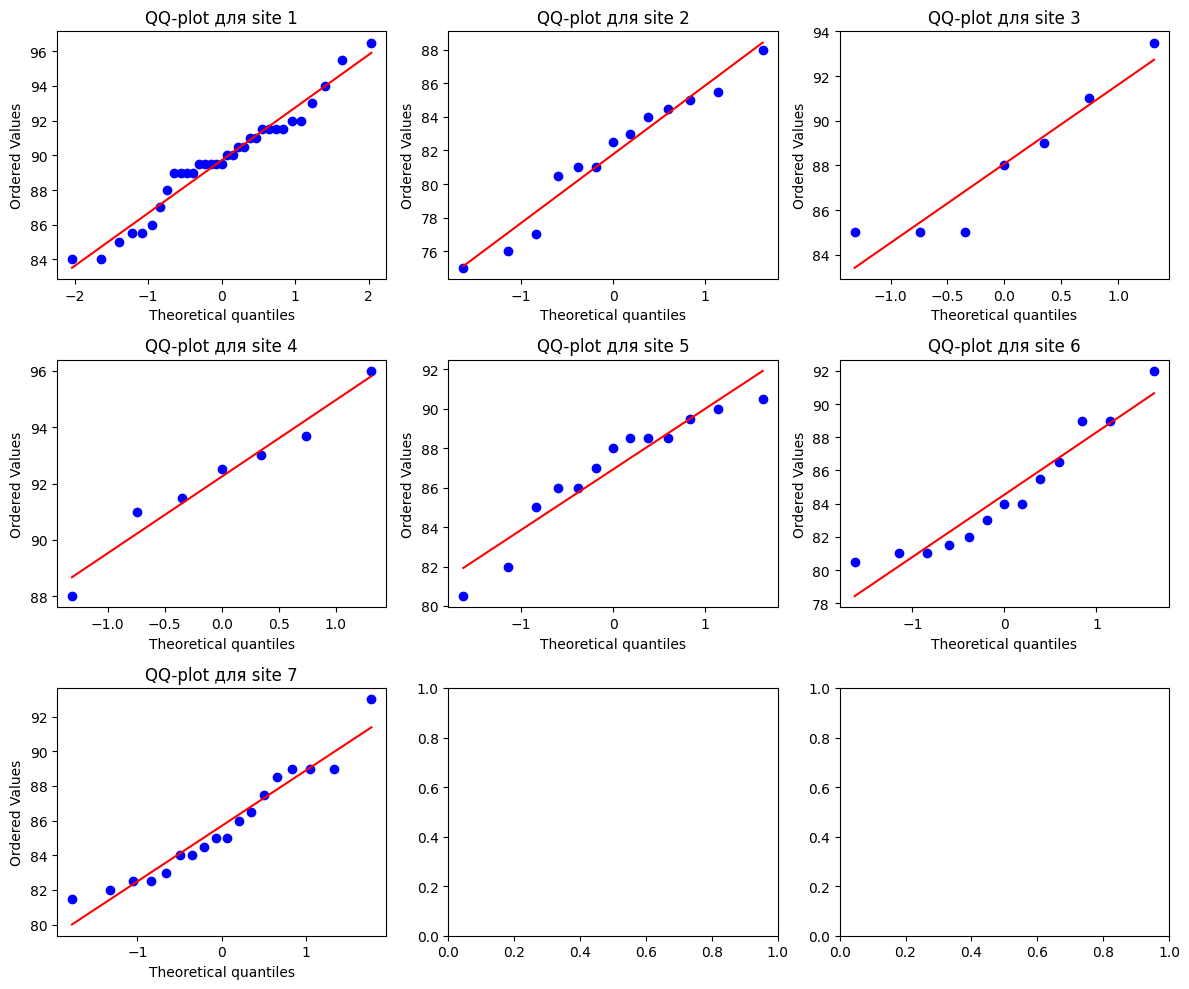

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, site in enumerate(data['site'].unique()):
    stats.probplot(data.loc[data['site'] == site, 'totlngth'], dist="norm", plot=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(f"QQ-plot для site {site}")
plt.tight_layout()
plt.show()

Для всех групп p > 0.05, нормальность не отвергается. Также на QQ-plot видна приблизительная линейность, что подтверждает нормальность распределения `totlngth` в каждой группе.

Проверим гомоскедастичность с помощью теста Левена.

In [28]:
stat_levene, p_levene = stats.levene(
    data.loc[data['site'] == 1, 'totlngth'],
    data.loc[data['site'] == 2, 'totlngth'],
    data.loc[data['site'] == 3, 'totlngth'],
    data.loc[data['site'] == 4, 'totlngth'],
    data.loc[data['site'] == 5, 'totlngth'],
    data.loc[data['site'] == 6, 'totlngth'],
    data.loc[data['site'] == 7, 'totlngth'],
)
print(
    f"Тест Левена: stat={stat_levene:.4f}, p={p_levene:.4f} - гомоскедастичность {'не отвергается' if p_levene > 0.05 else 'отвергается'}")

Тест Левена: stat=0.5032, p=0.8046 - гомоскедастичность не отвергается


По итогам всех проверок условий у нас есть основания для проведения однофакторного дисперсионного анализа, так как независимость наблюдений предполагается, нормальность распределения `totlngth` в каждой группе не отвергается, и гомоскедастичность также не отвергается.

#### Проведём однофакторный дисперсионный анализ

In [29]:
# Группируем данные по site и вычисляем необходимые суммы
grouped = data.groupby('site')['totlngth']
n_j = grouped.count()
X_bar_j = grouped.mean()
X_bar = data['totlngth'].mean()

In [30]:
# Вычисляем SSB и SSW
SSB = np.sum(n_j * (X_bar_j - X_bar) ** 2)
SSW = np.sum(grouped.apply(lambda x: np.sum((x - x.mean()) ** 2)))

In [31]:
# Степени свободы
k = len(n_j)
N = len(data)
df_between = k - 1
df_within = N - k

In [32]:
# Средние квадраты
MSB = SSB / df_between
MSW = SSW / df_within

In [33]:
# F-статистика и p-value
F_stat = MSB / MSW
p_value = stats.f.sf(F_stat, dfn=df_between, dfd=df_within)

In [34]:
print(f"F-статистика: {F_stat:.4f}")
# Также проверим с помощью функции из scipy
F_stat_scipy, p_value_scipy = stats.f_oneway(
    data.loc[data['site'] == 1, 'totlngth'],
    data.loc[data['site'] == 2, 'totlngth'],
    data.loc[data['site'] == 3, 'totlngth'],
    data.loc[data['site'] == 4, 'totlngth'],
    data.loc[data['site'] == 5, 'totlngth'],
    data.loc[data['site'] == 6, 'totlngth'],
    data.loc[data['site'] == 7, 'totlngth'],
)
print(f"F-статистика (scipy): {F_stat_scipy:.4f}")

F-статистика: 14.5817
F-статистика (scipy): 14.5817


In [35]:
print(f"p-value: {p_value:.6f}")
print(f"p-value (scipy): {p_value_scipy:.6f}")

p-value: 0.000000
p-value (scipy): 0.000000


p = 0 - модель статистически значима, есть различия в средней длине тела между группами. Результаты, полученные вручную и с помощью функции из scipy, совпадают.

# Задание № 3

Пусть i - целая часть среднего арифметического первых букв фамилий выполняющих работу по модулю 4. Тогда в зависимости от значения переменной вам достаётся модель:
* двухфакторного дисперсионного анализа
* ковариационного анализа (1 числовая переменная и 1 категориальная)
* логистическая регрессия
* регрессия Пуассона

Само задание
* Выберите подходящий датасет для вашей модели
* Воспользуйтесь соответствующей функцией из statsmodels, проинтерпретируйте результаты.

In [36]:
print("i =", (ord('В') + ord('Ш')) // 2 % 4)

i = 1


Нам достаётся ковариационный анализ (ANCOVA) - расширение дисперсионного анализа, которое позволяет учитывать влияние количественной переменной (ковариаты) при оценке эффекта категориального фактора на зависимую переменную. В ANCOVA мы проверяем, есть ли статистически значимые различия в средних значениях зависимой переменной между группами, при этом контролируя влияние одной или нескольких количественных переменных.

В предыдущей лабораторной мы узнали о том, что длина тела опоссумов сильно корелирована с длиной их головы. Поэтому в качестве ковариаты возьмём `hdlngth` - длину головы. Целевая переменная - `totlngth` - общая длина тела. Фактор - `site` - место поимки.

То есть мы хотим проверить, есть ли статистически значимые различия в средней длине тела между группами `site`, при этом контролируя влияние длины головы.

### Двуфакторный дисперсионный анализ

Гипотезы:
- $H0$: Средние значения зависимой переменной одинаковы во всех группах (нет эффекта фактора).
- $H1$: Хотя бы в одной группе среднее значение отличается (есть эффект фактора).

Условия для ANCOVA:
1. Независимость наблюдений
2. Нормальность распределения зависимой переменной в каждой группе
3. Гомоскедастичность - равенство дисперсий в группах
4. Линейная связь между зависимой переменной и ковариатой
5. Гомогенность регрессионных коэффициентов - эффект ковариаты должен быть одинаковым во всех группах
6. Ошибки должны быть нормально распределены

Уравнение модели ANCOVA:
$$ Y_{ij} = \mu + \tau_i + \beta (X_{ij} - \bar{X}) + \varepsilon_{ij} $$
где
- $Y_{ij}$ - значение зависимой переменной для наблюдения $j$ в группе $i$
- $\mu$ - общий средний
- $\tau_i$ - эффект группы $i$
- $\beta$ - коэффициент при ковариате
- $X_{ij}$ - значение ковариаты для наблюдения $j$ в группе $i$
- $\varepsilon_{ij}$ - ошибка

Проверим условие 4 - наличие линейной связи между `totlngth` и `hdlngth`. Для этого построим scatter plot.

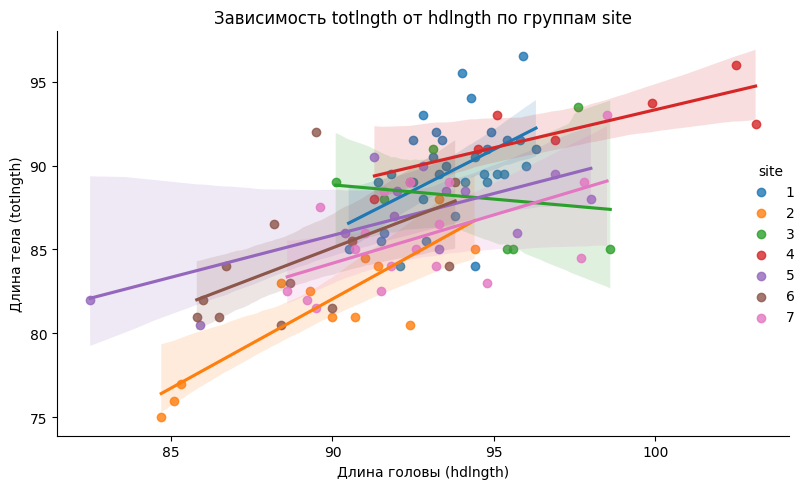

In [48]:
sns.lmplot(x='hdlngth', y='totlngth', hue='site', data=data, aspect=1.5)
plt.title("Зависимость totlngth от hdlngth по группам site")
plt.xlabel("Длина головы (hdlngth)")
plt.ylabel("Длина тела (totlngth)")
plt.tight_layout()
plt.show()

Проверим формально наличие линейной связи между `totlngth` и `hdlngth` в каждой группе `site` с помощью теста Пирсона.

In [53]:
for site in data['site'].unique():
    subset = data.loc[data['site'] == site]
    corr, p = stats.pearsonr(subset['hdlngth'], subset['totlngth'])
    print(
        f"Site {site}: r={corr:.4f}, p={p:.4f} - линейная связь {'подтверждается' if p < 0.05 else 'не подтверждается'}")

Site 1: r=0.4903, p=0.0038 - линейная связь есть
Site 2: r=0.8477, p=0.0003 - линейная связь есть
Site 3: r=-0.1581, p=0.7349 - линейная связь не подтверждается
Site 4: r=0.8013, p=0.0303 - линейная связь есть
Site 5: r=0.6993, p=0.0078 - линейная связь есть
Site 6: r=0.5532, p=0.0499 - линейная связь есть
Site 7: r=0.5488, p=0.0184 - линейная связь есть


По результатам теста Пирсона условие не соблюдается для site 3. Чтобы не нарушать условия ANCOVA, исключим эту группу из анализа.

In [57]:
data_ancova = data[data['site'] != 3].copy()

Проверим условие 5 - гомогенность регрессионных коэффициентов. Для этого попарно сравним угловые коэффициенты регрессии `totlngth` на `hdlngth` в каждой группе `site`. Если они не будут существенно отличаться, то условие будет выполнено.

In [69]:
sites = data_ancova['site'].unique()
for site1, site2 in combinations(sites, 2):
    subset1 = data_ancova.loc[data_ancova['site'] == site1]
    subset2 = data_ancova.loc[data_ancova['site'] == site2]
    slope1, _, _, _, _ = stats.linregress(subset1['hdlngth'], subset1['totlngth'])
    slope2, _, _, _, _ = stats.linregress(subset2['hdlngth'], subset2['totlngth'])
    if abs(slope1 - slope2) < 0.1:
        print(
            f"site {site1} и site {site2}: угловые коэффициенты похожи ({slope1:.4f} vs {slope2:.4f}) - условие выполняется")

site 1 и site 2: угловые коэффициенты похожи (0.9763 vs 1.0619) - условие выполняется
site 4 и site 5: угловые коэффициенты похожи (0.4532 vs 0.4992) - условие выполняется
site 5 и site 7: угловые коэффициенты похожи (0.4992 vs 0.5761) - условие выполняется


Из результатов видно, что большинство пар имеют разные угловые коэффициенты, но (4, 5) и (5, 7) имеют похожие значения. Значит оставим в анализе эту тройку групп и исключим остальные.

In [70]:
data_ancova = data_ancova[data_ancova['site'].isin([4, 5, 7])].copy()

In [77]:
data_ancova['site'].value_counts()

site
7    18
5    13
4     7
Name: count, dtype: int64

Теперь у нас есть 3 группы (site 4, 5, 7), для которых выполняются все условия ANCOVA. Проведём анализ с помощью функции `ols` из `statsmodels`.

Создадим модель, в которой `totlngth` - зависимая переменная, `site` - категориальный фактор, а `hdlngth` - ковариата. Затем проведём ANOVA по этой модели, чтобы проверить значимость фактора `site` после контроля за `hdlngth`. Параметр `typ=2` в функции `anova_lm` указывает на использование второго типа сумм квадратов, который подходит для моделей с неравными размерами групп.

In [74]:
model = ols('totlngth ~ C(site) + hdlngth', data=data_ancova).fit()
print(sm.stats.anova_lm(model, typ=2))

              sum_sq    df          F    PR(>F)
C(site)    67.295015   2.0   6.182504  0.005128
hdlngth   125.428902   1.0  23.046720  0.000031
Residual  185.040762  34.0        NaN       NaN


Проверим 6-е условие - нормальность остатков модели. Для этого построим QQ-plot и проведём тест Шапиро-Уилка.

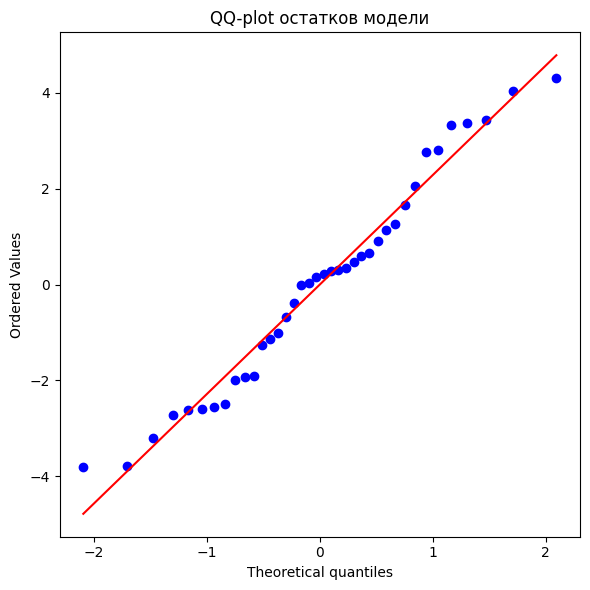

In [79]:
residuals = model.resid
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("QQ-plot остатков модели")
plt.tight_layout()
plt.show()

In [80]:
stat_sw, p_sw = stats.shapiro(residuals)
print(f"Шапиро-Уилк: W={stat_sw:.4f}, p={p_sw:.4f} - нормальность {'не отвергается' if p_sw > 0.05 else 'отвергается'}")

Шапиро-Уилк: W=0.9651, p=0.2760 - нормальность не отвергается


Из результатов ANCOVA можно сделать выводы:
* Влияние ковариаты: Длина головы оказывает статистически значимое влияние на общую длину тела. Это подтверждает, что часть различий в размерах особей объясняется их физиологическими пропорциями.
* Влияние фактора: После исключения влияния длины головы, фактор места обитания остается высокозначимым.

Итог: Различия в длине тела между сайтами 4, 5 и 7 обусловлены не только разным размером головы животных, но и специфическими особенностями самих локаций (может быть, экологическими условиями или кормовой базой).